<img src="../imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a|
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a|
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a|
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# Gráficos de distribuições para a AV3

Notebook-fonte para gerar figuras didáticas usadas no guia de estudos da AV3.

As figuras são teóricas, reproduzíveis e geradas com `scipy.stats`, sem simulação aleatória como base principal.


In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path("../.matplotlib").resolve())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

OUT_DIR = Path("../imgs").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#2563eb"
GREEN = "#16a34a"
ORANGE = "#f97316"
RED = "#dc2626"
GRAY = "#6b7280"
LIGHT_BLUE = "#bfdbfe"

def save_fig(fig, filename):
    path = OUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return path

generated = []


## Distribuições discretas


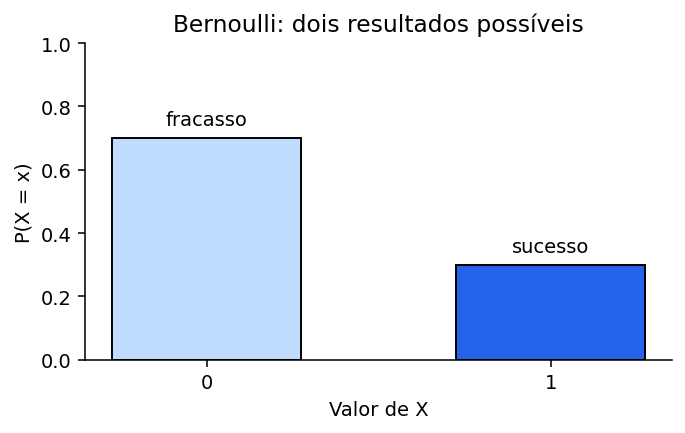

In [2]:
x = np.array([0, 1])
p = 0.3
pmf = stats.bernoulli.pmf(x, p)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(x, pmf, width=0.55, color=[LIGHT_BLUE, BLUE], edgecolor="black")
ax.set_xticks(x)
ax.set_ylim(0, 1)
ax.set_xlabel("Valor de X")
ax.set_ylabel("P(X = x)")
ax.set_title("Bernoulli: dois resultados possíveis")
ax.text(0, pmf[0] + 0.04, "fracasso", ha="center")
ax.text(1, pmf[1] + 0.04, "sucesso", ha="center")
generated.append(save_fig(fig, "dist_bernoulli_pmf.png"))


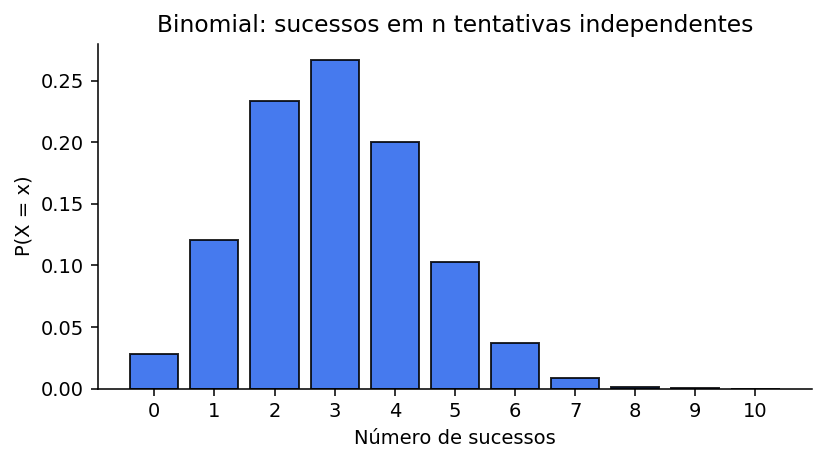

In [3]:
n, p = 10, 0.3
x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n=n, p=p)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(x, pmf, color=BLUE, edgecolor="black", alpha=0.85)
ax.set_xlabel("Número de sucessos")
ax.set_ylabel("P(X = x)")
ax.set_title("Binomial: sucessos em n tentativas independentes")
ax.set_xticks(x)
generated.append(save_fig(fig, "dist_binomial_pmf.png"))


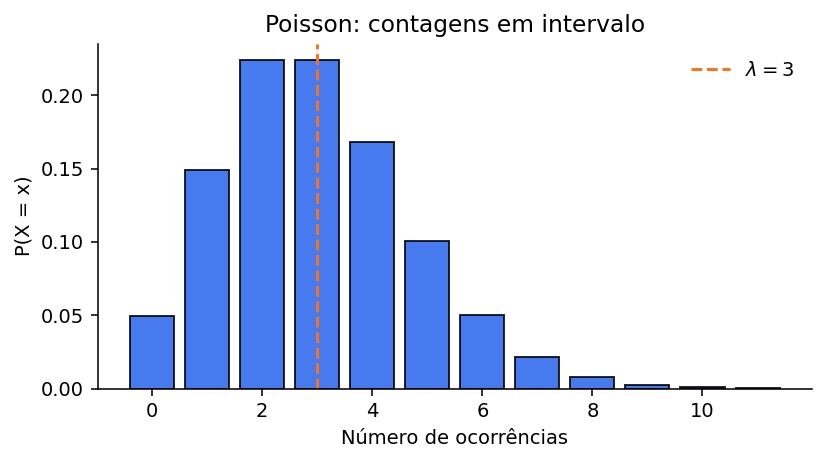

In [4]:
lam = 3
x = np.arange(0, 12)
pmf = stats.poisson.pmf(x, mu=lam)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(x, pmf, color=BLUE, edgecolor="black", alpha=0.85)
ax.axvline(lam, color=ORANGE, linestyle="--", label=r"$\lambda=3$")
ax.set_xlabel("Número de ocorrências")
ax.set_ylabel("P(X = x)")
ax.set_title("Poisson: contagens em intervalo")
ax.legend(frameon=False)
generated.append(save_fig(fig, "dist_poisson_pmf.png"))


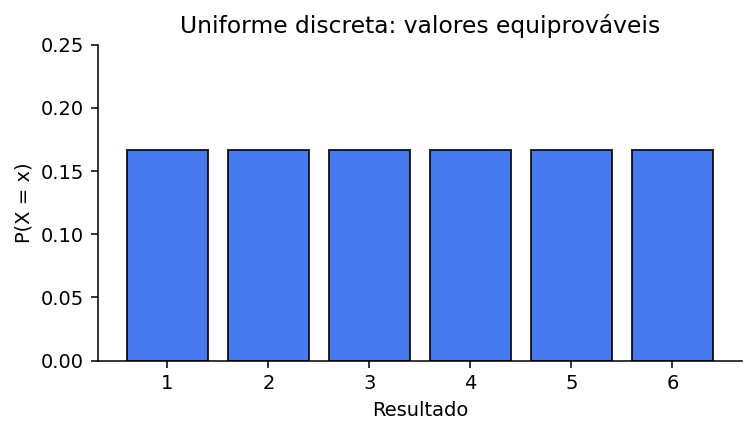

In [5]:
x = np.arange(1, 7)
pmf = np.repeat(1 / len(x), len(x))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(x, pmf, color=BLUE, edgecolor="black", alpha=0.85)
ax.set_xticks(x)
ax.set_ylim(0, 0.25)
ax.set_xlabel("Resultado")
ax.set_ylabel("P(X = x)")
ax.set_title("Uniforme discreta: valores equiprováveis")
generated.append(save_fig(fig, "dist_uniforme_discreta_pmf.png"))


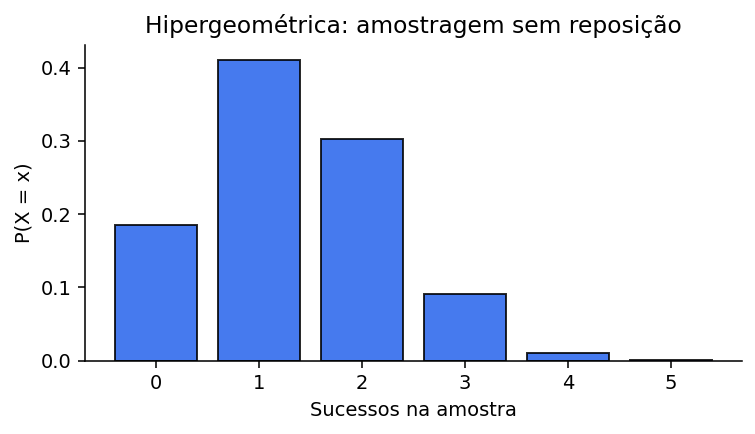

In [6]:
N, K, n = 30, 8, 5
x_min = max(0, n - (N - K))
x_max = min(K, n)
x = np.arange(x_min, x_max + 1)
pmf = stats.hypergeom.pmf(x, M=N, n=K, N=n)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar(x, pmf, color=BLUE, edgecolor="black", alpha=0.85)
ax.set_xticks(x)
ax.set_xlabel("Sucessos na amostra")
ax.set_ylabel("P(X = x)")
ax.set_title("Hipergeométrica: amostragem sem reposição")
generated.append(save_fig(fig, "dist_hipergeometrica_pmf.png"))


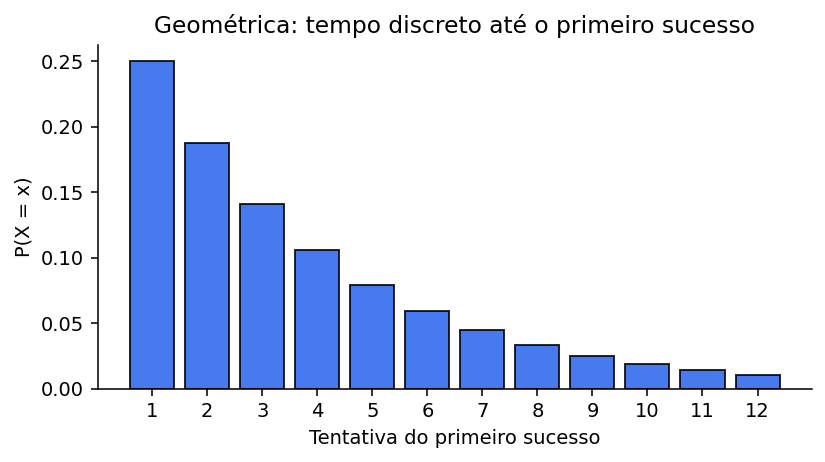

In [7]:
p = 0.25
x = np.arange(1, 13)
pmf = stats.geom.pmf(x, p=p)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(x, pmf, color=BLUE, edgecolor="black", alpha=0.85)
ax.set_xticks(x)
ax.set_xlabel("Tentativa do primeiro sucesso")
ax.set_ylabel("P(X = x)")
ax.set_title("Geométrica: tempo discreto até o primeiro sucesso")
generated.append(save_fig(fig, "dist_geometrica_pmf.png"))


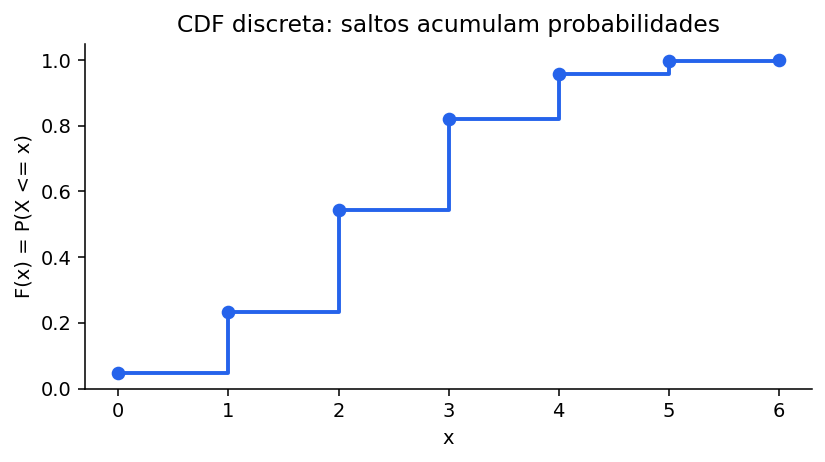

In [8]:
n, p = 6, 0.4
x = np.arange(0, n + 1)
cdf = stats.binom.cdf(x, n=n, p=p)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.step(x, cdf, where="post", color=BLUE, linewidth=2)
ax.scatter(x, cdf, color=BLUE, zorder=3)
ax.set_ylim(0, 1.05)
ax.set_xlabel("x")
ax.set_ylabel("F(x) = P(X <= x)")
ax.set_title("CDF discreta: saltos acumulam probabilidades")
generated.append(save_fig(fig, "dist_discreta_cdf_degraus.png"))


## Distribuições contínuas


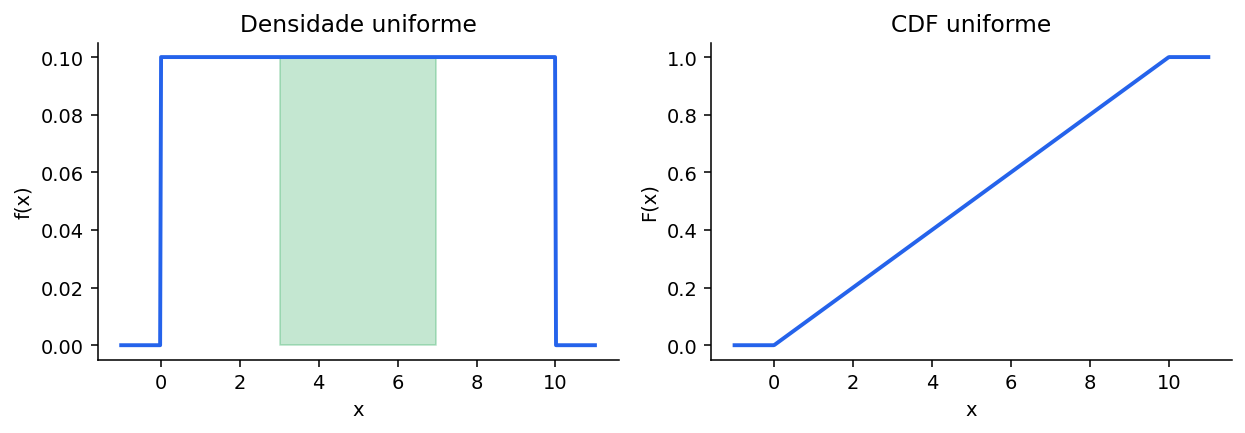

In [9]:
a, b = 0, 10
x = np.linspace(a - 1, b + 1, 500)
pdf = stats.uniform.pdf(x, loc=a, scale=b - a)
cdf = stats.uniform.cdf(x, loc=a, scale=b - a)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(x, pdf, color=BLUE, linewidth=2)
axes[0].fill_between(x, 0, pdf, where=(x >= 3) & (x <= 7), color=GREEN, alpha=0.25)
axes[0].set_title("Densidade uniforme")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[1].plot(x, cdf, color=BLUE, linewidth=2)
axes[1].set_title("CDF uniforme")
axes[1].set_xlabel("x")
axes[1].set_ylabel("F(x)")
generated.append(save_fig(fig, "dist_uniforme_continua_pdf_cdf.png"))


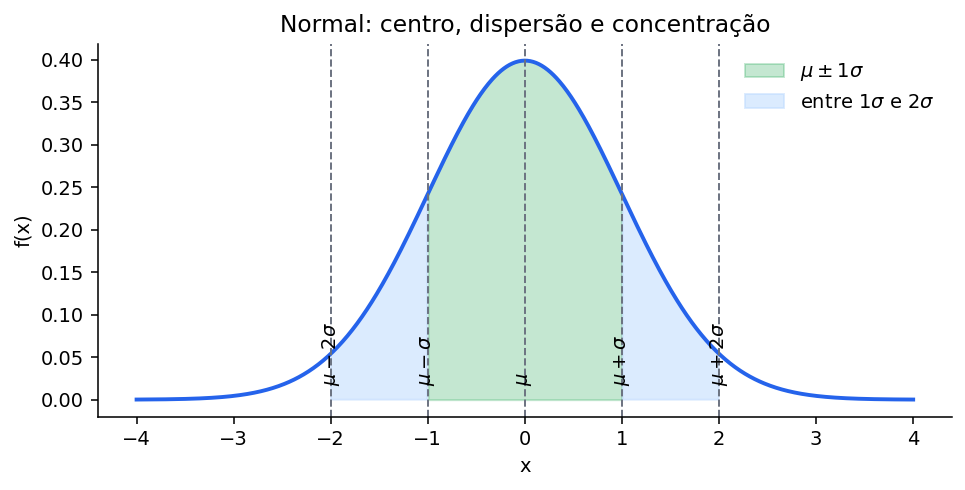

In [10]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 800)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(x, pdf, color=BLUE, linewidth=2)
ax.fill_between(x, 0, pdf, where=(x >= -1) & (x <= 1), color=GREEN, alpha=0.25, label=r"$\mu\pm1\sigma$")
ax.fill_between(x, 0, pdf, where=((x >= -2) & (x < -1)) | ((x > 1) & (x <= 2)), color=LIGHT_BLUE, alpha=0.55, label=r"entre $1\sigma$ e $2\sigma$")
for value, label in [(0, r"$\mu$"), (-1, r"$\mu-\sigma$"), (1, r"$\mu+\sigma$"), (-2, r"$\mu-2\sigma$"), (2, r"$\mu+2\sigma$")]:
    ax.axvline(value, color=GRAY, linestyle="--", linewidth=1)
    ax.text(value, max(pdf) * 0.04, label, ha="center", va="bottom", rotation=90)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Normal: centro, dispersão e concentração")
ax.legend(frameon=False, loc="upper right")
generated.append(save_fig(fig, "dist_normal_desvios.png"))


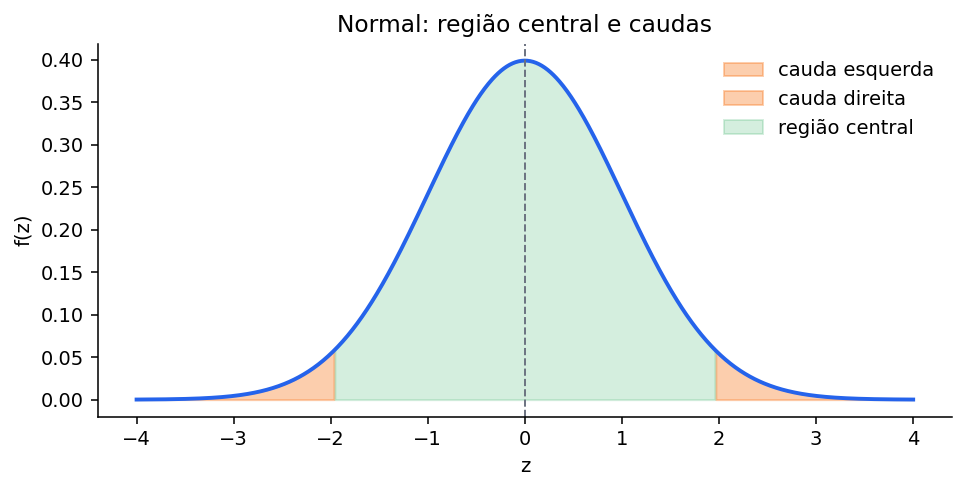

In [11]:
mu, sigma = 0, 1
x = np.linspace(-4, 4, 800)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(x, pdf, color=BLUE, linewidth=2)
ax.fill_between(x, 0, pdf, where=(x <= -1.96), color=ORANGE, alpha=0.35, label="cauda esquerda")
ax.fill_between(x, 0, pdf, where=(x >= 1.96), color=ORANGE, alpha=0.35, label="cauda direita")
ax.fill_between(x, 0, pdf, where=(x > -1.96) & (x < 1.96), color=GREEN, alpha=0.18, label="região central")
ax.axvline(mu, color=GRAY, linestyle="--", linewidth=1)
ax.set_xlabel("z")
ax.set_ylabel("f(z)")
ax.set_title("Normal: região central e caudas")
ax.legend(frameon=False, loc="upper right")
generated.append(save_fig(fig, "dist_normal_caudas.png"))


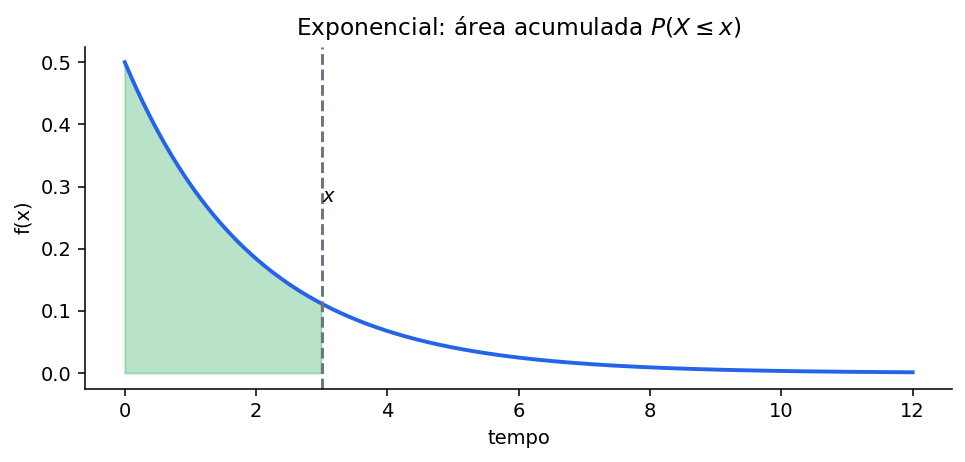

In [12]:
lam = 0.5
x = np.linspace(0, 12, 800)
pdf = stats.expon.pdf(x, loc=0, scale=1 / lam)
cutoff = 3

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(x, pdf, color=BLUE, linewidth=2)
ax.fill_between(x, 0, pdf, where=(x <= cutoff), color=GREEN, alpha=0.3)
ax.axvline(cutoff, color=GRAY, linestyle="--")
ax.text(cutoff, max(pdf) * 0.55, r"$x$", ha="left")
ax.set_xlabel("tempo")
ax.set_ylabel("f(x)")
ax.set_title(r"Exponencial: área acumulada $P(X\leq x)$")
generated.append(save_fig(fig, "dist_exponencial_acumulada.png"))


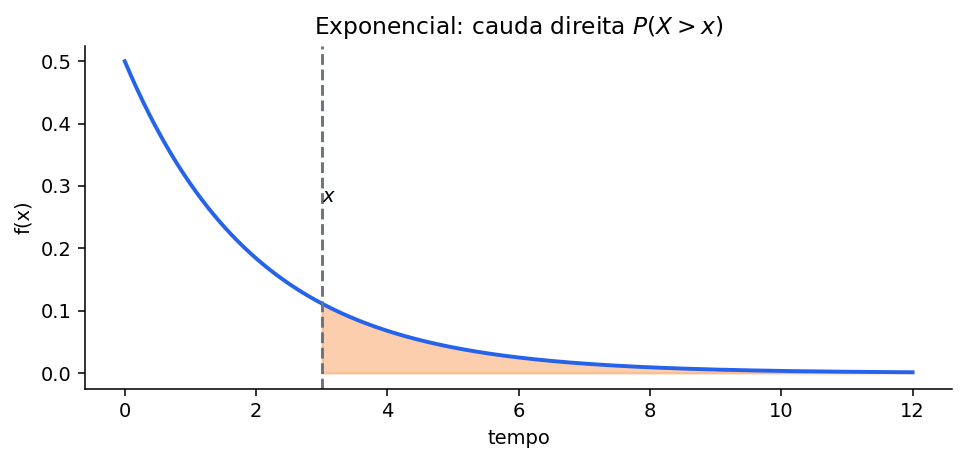

In [13]:
lam = 0.5
x = np.linspace(0, 12, 800)
pdf = stats.expon.pdf(x, loc=0, scale=1 / lam)
cutoff = 3

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(x, pdf, color=BLUE, linewidth=2)
ax.fill_between(x, 0, pdf, where=(x >= cutoff), color=ORANGE, alpha=0.35)
ax.axvline(cutoff, color=GRAY, linestyle="--")
ax.text(cutoff, max(pdf) * 0.55, r"$x$", ha="left")
ax.set_xlabel("tempo")
ax.set_ylabel("f(x)")
ax.set_title(r"Exponencial: cauda direita $P(X>x)$")
generated.append(save_fig(fig, "dist_exponencial_sobrevivencia.png"))


In [14]:
pd.DataFrame({"arquivo": [p.name for p in generated]})


,arquivo
0,dist_bernoulli_pmf.png
1,dist_binomial_pmf.png
2,dist_poisson_pmf.png
3,dist_uniforme_discreta_pmf.png
4,dist_hipergeometrica_pmf.png
5,dist_geometrica_pmf.png
6,dist_discreta_cdf_degraus.png
7,dist_uniforme_continua_pdf_cdf.png
8,dist_normal_desvios.png
9,dist_normal_caudas.png
